In [ ]:
#########===============  price --------------> area (parameter)   <---------------------==========model###############333

In [177]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [178]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [179]:
### Loading dataset

df=pd.read_csv("MagicBricks.csv")

In [180]:
df

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft
0,800.0,3,2.0,Semi-Furnished,Rohini Sector 25,1.0,6500000,Ready_to_move,New_Property,Builder_Floor,NaN
1,750.0,2,2.0,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1.0,5000000,Ready_to_move,New_Property,Apartment,6667.0
2,950.0,2,2.0,Furnished,"Citizen Apartment, Rohini Sector 13",1.0,15500000,Ready_to_move,Resale,Apartment,6667.0
3,600.0,2,2.0,Semi-Furnished,Rohini Sector 24,1.0,4200000,Ready_to_move,Resale,Builder_Floor,6667.0
4,650.0,2,2.0,Semi-Furnished,Rohini Sector 24 carpet area 650 sqft status R...,1.0,6200000,Ready_to_move,New_Property,Builder_Floor,6667.0
...,...,...,...,...,...,...,...,...,...,...,...
1254,4118.0,4,5.0,Unfurnished,Chittaranjan Park,3.0,55000000,Ready_to_move,New_Property,Builder_Floor,12916.0
1255,1050.0,3,2.0,Semi-Furnished,Chittaranjan Park,3.0,12500000,Ready_to_move,Resale,Builder_Floor,12916.0
1256,875.0,3,3.0,Semi-Furnished,Chittaranjan Park,3.0,17500000,Ready_to_move,New_Property,Builder_Floor,12916.0
1257,990.0,2,2.0,Unfurnished,Chittaranjan Park Block A,1.0,11500000,Ready_to_move,Resale,Builder_Floor,12916.0


In [181]:
df.head()


,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft
0,800.0,3,2.0,Semi-Furnished,Rohini Sector 25,1.0,6500000,Ready_to_move,New_Property,Builder_Floor,NaN
1,750.0,2,2.0,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1.0,5000000,Ready_to_move,New_Property,Apartment,6667.0
2,950.0,2,2.0,Furnished,"Citizen Apartment, Rohini Sector 13",1.0,15500000,Ready_to_move,Resale,Apartment,6667.0
3,600.0,2,2.0,Semi-Furnished,Rohini Sector 24,1.0,4200000,Ready_to_move,Resale,Builder_Floor,6667.0
4,650.0,2,2.0,Semi-Furnished,Rohini Sector 24 carpet area 650 sqft status R...,1.0,6200000,Ready_to_move,New_Property,Builder_Floor,6667.0


In [182]:
## uderstanding data

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Area         1259 non-null   float64
 1   BHK          1259 non-null   int64  
 2   Bathroom     1257 non-null   float64
 3   Furnishing   1254 non-null   str    
 4   Locality     1259 non-null   str    
 5   Parking      1226 non-null   float64
 6   Price        1259 non-null   int64  
 7   Status       1259 non-null   str    
 8   Transaction  1259 non-null   str    
 9   Type         1254 non-null   str    
 10  Per_Sqft     1018 non-null   float64
dtypes: float64(4), int64(2), str(5)
memory usage: 108.3 KB


In [183]:
df.describe()

,Area,BHK,Bathroom,Parking,Price,Per_Sqft
count,1259.000000,1259.000000,1257.000000,1226.000000,1.259000e+03,1018.000000
mean,1466.452724,2.796664,2.556086,1.935563,2.130670e+07,15690.136542
std,1568.055040,0.954425,1.042220,6.279212,2.560115e+07,21134.738568
min,28.000000,1.000000,1.000000,1.000000,1.000000e+06,1259.000000
25%,800.000000,2.000000,2.000000,1.000000,5.700000e+06,6364.000000
50%,1200.000000,3.000000,2.000000,1.000000,1.420000e+07,11291.500000
75%,1700.000000,3.000000,3.000000,2.000000,2.550000e+07,18000.000000
max,24300.000000,10.000000,7.000000,114.000000,2.400000e+08,183333.000000


In [184]:
##### removing outliers
df = df[df['Area'] < 10000]

In [185]:
df

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft
0,800.0,3,2.0,Semi-Furnished,Rohini Sector 25,1.0,6500000,Ready_to_move,New_Property,Builder_Floor,NaN
1,750.0,2,2.0,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1.0,5000000,Ready_to_move,New_Property,Apartment,6667.0
2,950.0,2,2.0,Furnished,"Citizen Apartment, Rohini Sector 13",1.0,15500000,Ready_to_move,Resale,Apartment,6667.0
3,600.0,2,2.0,Semi-Furnished,Rohini Sector 24,1.0,4200000,Ready_to_move,Resale,Builder_Floor,6667.0
4,650.0,2,2.0,Semi-Furnished,Rohini Sector 24 carpet area 650 sqft status R...,1.0,6200000,Ready_to_move,New_Property,Builder_Floor,6667.0
...,...,...,...,...,...,...,...,...,...,...,...
1253,1200.0,3,3.0,Semi-Furnished,Chittaranjan Park,1.0,16500000,Ready_to_move,Resale,Builder_Floor,12916.0
1254,4118.0,4,5.0,Unfurnished,Chittaranjan Park,3.0,55000000,Ready_to_move,New_Property,Builder_Floor,12916.0
1255,1050.0,3,2.0,Semi-Furnished,Chittaranjan Park,3.0,12500000,Ready_to_move,Resale,Builder_Floor,12916.0
1256,875.0,3,3.0,Semi-Furnished,Chittaranjan Park,3.0,17500000,Ready_to_move,New_Property,Builder_Floor,12916.0


In [186]:
df = df[df['Price'] < 100000000]

In [187]:
df

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft
0,800.0,3,2.0,Semi-Furnished,Rohini Sector 25,1.0,6500000,Ready_to_move,New_Property,Builder_Floor,NaN
1,750.0,2,2.0,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1.0,5000000,Ready_to_move,New_Property,Apartment,6667.0
2,950.0,2,2.0,Furnished,"Citizen Apartment, Rohini Sector 13",1.0,15500000,Ready_to_move,Resale,Apartment,6667.0
3,600.0,2,2.0,Semi-Furnished,Rohini Sector 24,1.0,4200000,Ready_to_move,Resale,Builder_Floor,6667.0
4,650.0,2,2.0,Semi-Furnished,Rohini Sector 24 carpet area 650 sqft status R...,1.0,6200000,Ready_to_move,New_Property,Builder_Floor,6667.0
...,...,...,...,...,...,...,...,...,...,...,...
1253,1200.0,3,3.0,Semi-Furnished,Chittaranjan Park,1.0,16500000,Ready_to_move,Resale,Builder_Floor,12916.0
1254,4118.0,4,5.0,Unfurnished,Chittaranjan Park,3.0,55000000,Ready_to_move,New_Property,Builder_Floor,12916.0
1255,1050.0,3,2.0,Semi-Furnished,Chittaranjan Park,3.0,12500000,Ready_to_move,Resale,Builder_Floor,12916.0
1256,875.0,3,3.0,Semi-Furnished,Chittaranjan Park,3.0,17500000,Ready_to_move,New_Property,Builder_Floor,12916.0


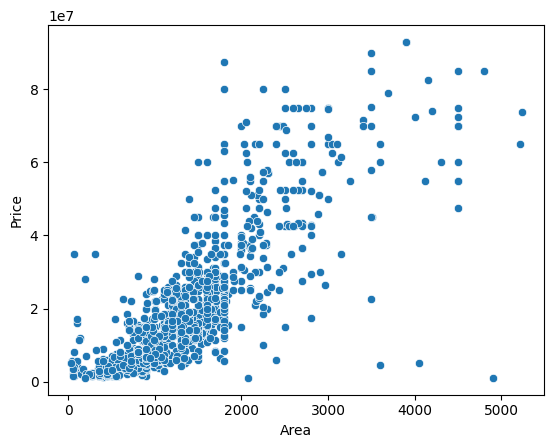

In [188]:
sns.scatterplot(x='Area', y='Price', data=df)
plt.show()

In [189]:
print(df[['Area', 'Price']].corr())

           Area     Price
Area   1.000000  0.817223
Price  0.817223  1.000000


In [190]:
##### select feautres

x=df[['Area']]
y=df['Price']

In [191]:
x

,Area
0,800.0
1,750.0
2,950.0
3,600.0
4,650.0
...,...
1253,1200.0
1254,4118.0
1255,1050.0
1256,875.0


In [192]:
y

0        6500000
1        5000000
2       15500000
3        4200000
4        6200000
          ...   
1253    16500000
1254    55000000
1255    12500000
1256    17500000
1257    11500000
Name: Price, Length: 1231, dtype: int64

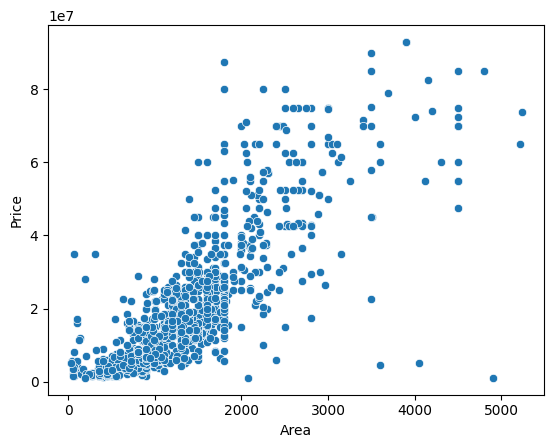

In [193]:
########## Exploratory data analysis

sns.scatterplot(x='Area',y='Price',data=df)
plt.show()

In [194]:
#### SORT OF LINEAR DATA

In [195]:
######### Train test split

X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [196]:
X_train


,Area
1087,1250.0
916,1500.0
436,1800.0
1254,4118.0
828,540.0
...,...
1062,1590.0
1113,1640.0
1150,1600.0
877,350.0


In [197]:
X_test

,Area
563,1800.0
1068,2175.0
251,3500.0
568,2475.0
1185,900.0
...,...
89,1525.0
651,1700.0
308,650.0
386,270.0


In [198]:
y_train

1087     5800000
916     13000000
436     50000000
1254    55000000
828      1700000
          ...   
1062    25000000
1113    12000000
1150    20000000
877      3000000
1146    26000000
Name: Price, Length: 984, dtype: int64

In [199]:
y_test

563     32500000
1068    44000000
251     90000000
568     31000000
1185    15000000
          ...   
89      14200000
651     17200000
308      5800000
386      2300000
771      6000000
Name: Price, Length: 247, dtype: int64

In [200]:
model = LinearRegression()

In [201]:
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [202]:
y_pred=model.predict(X_test)

In [203]:
y_pred

array([27675618.98743619, 34580948.99121553, 58979781.6712359 ,
       40105212.99423902, 11102826.97836576, 35962014.9919714 ,
       11102826.97836576, 19389222.98290098, 22151354.98441271,
       11102826.97836576, 11102826.97836576, 11931466.57881928,
       12944248.31270692, 46089832.33084778, 22722195.59805847,
       31358461.65611851, 21322715.38395919, 11102826.97836576,
       31358461.65611851, 11102826.97836576, 49772674.9995301 ,
        7788268.57655167, 16627090.98138924, 15706380.31421866,
       58979781.6712359 , -4825467.56368526, 25373842.31950974,
       11102826.97836576, 11102826.97836576, 15338096.04735043,
        4657852.3081717 , -1823950.78870917, 20309933.65007155,
       12944248.31270692, 20309933.65007155, 19389222.98290098,
       35962014.9919714 , 12944248.31270692,  8340694.97685402,
       -4088899.0299488 , 18284370.18229628, 23072065.6515833 ,
       -1787122.36202235,  8340694.97685402, 23072065.6515833 ,
       -4641325.43025115, 29517040.32177

In [204]:
model.predict([[800]])

C:\Users\KIIT\OneDrive\Desktop\mlprojects\machine-learning-projects\ml\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([9261405.6440246])

In [205]:
m = model.coef_[0]
b = model.intercept_

In [206]:
m

np.float64(18414.21334341159)

In [207]:
b

np.float64(-5469965.03070467)

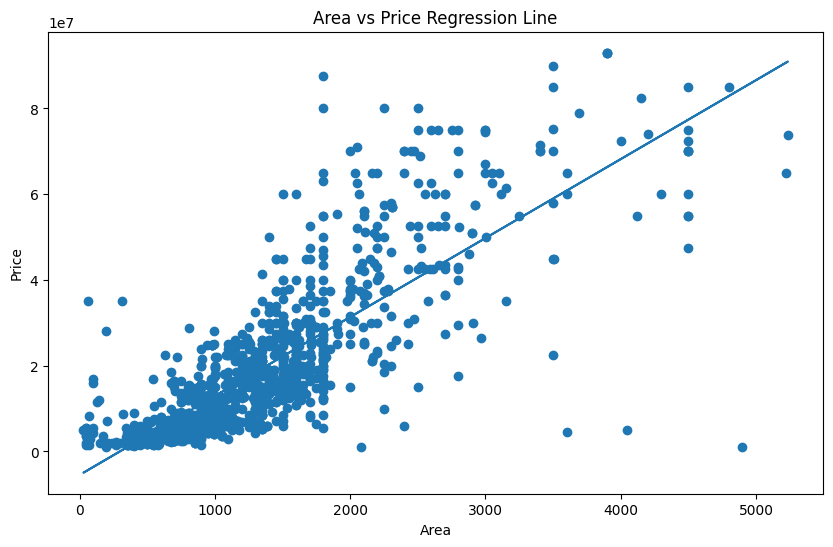

In [208]:
plt.figure(figsize=(10,6))

plt.scatter(x, y)

plt.plot(x, model.predict(x))

plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Area vs Price Regression Line")

plt.show()

In [209]:
price = m*800+b

In [210]:
price

np.float64(9261405.644024601)

In [211]:
price = m*1000+b

In [212]:
price

np.float64(12944248.312706921)

In [213]:
##### model absolute error
mae = mean_absolute_error(y_test, y_pred)

In [214]:
mae

6711408.065827831

In [215]:
##### mean squared error
mse = mean_squared_error(y_test, y_pred)

In [216]:
mse

97230112756681.72

In [217]:
#### rmse
rmse = np.sqrt(mse)

In [218]:
rmse

np.float64(9860533.086840779)

In [219]:
######### r2_score
r2 = r2_score(y_test, y_pred)

In [220]:
r2

0.7077276440853305